# Ion Liquid Selection and Reactor-Separator Network Optimization

This script solves a QUBO model for the discrete part of ionic liquid selection and process network optimization problem using simulated annealing, quantum annealing (dwave), and entropy quantum computing (dirac-1). 
The IP formulation of the discrete part of the original problem is documented in "ilrs_discrete_IP.jl" file. In the same file, the JuMP model is converted to a QUBO model using QUBO.jl package, and the resulting QUBO model is exported for use in Python environment.  

The problem involves selecting ionic liquids for a reactor-separator network design, where the goal is to minimize the total cost while satisfying various flow constraints. It is formulated as an integer programming to select ionic liquids and reactor-separator network based on various logical constraints, formulated as linear and/or quadratic constraints. See the "ilrs_discrete_IP.jl" file for the details of the model and Gurobi solver. 

The original MINLP problem is adapted from the following source:

    Iftakher, A., & Hasan, M. M. F. (2024). Exploring quantum optimization for computer-aided Molecular and Process Design. Systems and Control Transactions, 3, 292–299. https://psecommunity.org/LAPSE:2024.1540


In [ ]:
import sys
sys.path.append('..')  # Adds the parent directory (il-rxtor-sep-opt) to the path

import pandas as pd
from ilrs_common import *
from ilrs_plotting import *


# DATA COLLECTION 
## Import QUBO model and solve using different methods 

In [ ]:
# Import Q matrix and scalars from the Julia export (QUBO model)
Q_filepath = "./julia_exports/Q_matrix_1.csv"
L_filepath = "./julia_exports/L_vector_1.csv"
scalars_filepath = "./julia_exports/scalars_1.csv"

Q, beta = import_from_julia(scalars_filepath, Q_filepath, L_filepath)

In [ ]:
# ================ DWave neal / SA ==========================
simAnnSamples, t_simAnn = solve_sim_annealing(Q, beta, save=True)

# ================ DWave / QA ==========================
# Solve the QUBO model using Dwave quantum annealer 
# Execution time includes embedding time + solving time 
DWaveSamples, tts_qa = solve_qa_dwave(Q, beta, save=True)

# ================ QCI dirac-1 / EQC ==========================
# Solve the QUBO model using QCI dirac-1 / EQC 
file_name = "il-rs_mip_decomp.json"
qci_result, job_body, job_response = solve_eqc_qci(Q, beta, file_name, num_sample=100, jobinfo=True)

# Save the QCI result to pandas DF and a CSV file
qci_result_df = sampleset_to_df(qci_result, imported=True, qci=True)
t_qci = qci_result['execution_time']

In [ ]:
# ========== Data Processing ==========
# Convert the results to a dataframe 
dwave_df_raw = DWaveSamples.to_pandas_dataframe()
simAnn_df_raw = simAnnSamples.to_pandas_dataframe()

df_list = [dwave_df_raw, simAnn_df_raw, qci_result_df]
df_names = [ 'DWave_QA','SimAnnealing', 'QCI_EQC']

# Use a function to extract energy and probability data only and convert to dataframe
dwave_df = sampleset_to_df(DWaveSamples)
simAnn_df = sampleset_to_df(simAnnSamples)

## DATA ANALYSIS 

These results may be collected from DATA COLLECTION section or imported from saved files. 

In [13]:
# ========== Get saved results from csv files for data analysis ==========
# Simulated annealing results
simAnn_file = 'result_raw/SimAnnealing_sampleset.csv'
simAnn_sampleset = pd.read_csv(simAnn_file)
simAnn_df = sampleset_to_df(simAnn_sampleset, imported=True)

# DWave QA results 
dwave_qa_result_file = 'result_raw/DWave_QA_sampleset.csv'
dwave_qa_timing_info = 'result_raw/Dwave_QA_run_info.txt'

dwave_sampleset = pd.read_csv(dwave_qa_result_file)
dwave_df = sampleset_to_df(dwave_sampleset, imported=True)

timing_info, dwave_qa_tts_total = import_qa_timing_info(dwave_qa_timing_info)
dwave_qa_tts_qc = timing_info['qpu_access_time'] / 1e6 # conversion to seconds

# QCI results
qci_result_file = 'result_raw/QCI_EQC.csv'
qci_result_df = pd.read_csv(qci_result_file)
qci_result_df = qci_result_df.set_index('Energy')
# total execution time for qci results 
t_qci = qci_result_df.iloc[0]['Execution_Time']  # Get the first value of the execution time

Timing Info: {'post_processing_overhead_time': 32.0, 'qpu_access_overhead_time': 1732.64, 'qpu_access_time': 134802.36, 'qpu_anneal_time_per_sample': 20.0, 'qpu_delay_time_per_sample': 20.58, 'qpu_programming_time': 15762.36, 'qpu_readout_time_per_sample': 78.46, 'qpu_sampling_time': 119040.0, 'total_post_processing_time': 32.0}
TTS Tictoc Info: 1.5889837741851807


In [14]:
# ========== Calculate time-to-solution (tts) ==========
feas_ub = 57        # upper bound for feasible solution, taken from Gurobi result
opt_ub = 19.1       # upper bound for optimal solution, taken from Gurobi result

# Calculate the time to solution for the feasible solutions (tts_f) and optimal solutions (tts_opt)
sa_tts_f = calculate_tts(simAnnSamples, t_simAnn, feas_ub)
sa_tts_opt = calculate_tts(simAnnSamples, t_simAnn, opt_ub)
qci_tts_f = calculate_tts(qci_result_df, t_qci, feas_ub)
qci_tts_opt = calculate_tts(qci_result_df, t_qci, opt_ub)
dwave_total_tts_f = calculate_tts(dwave_sampleset, dwave_qa_tts_total, feas_ub)
dwave_total_tts_opt = calculate_tts(dwave_sampleset, dwave_qa_tts_total, opt_ub)
dwave_qc_tts_f = calculate_tts(dwave_sampleset, dwave_qa_tts_qc, feas_ub)
dwave_qc_tts_opt = calculate_tts(dwave_sampleset, dwave_qa_tts_qc, opt_ub)

tts_feas = {'SA': sa_tts_f, 'QA-DWAVE_qpu': dwave_qc_tts_f, 'QA-DWAVE_total': dwave_total_tts_f, 'EQC-QCI_qpu': qci_tts_f}
tts_opt = {'SA': sa_tts_opt, 'QA-DWAVE_qpu': dwave_qc_tts_opt, 'QA-DWAVE_total': dwave_total_tts_opt, 'EQC-QCI_qpu': qci_tts_opt}

# Format each value to 1 decimal place
formatted_tts_feas = {k: f"{v:.2f}" for k, v in tts_feas.items()}
formatted_tts_opt = {k: f"{v:.2f}" for k, v in tts_opt.items()}

df_tts = pd.DataFrame({
    'TTS_feas': formatted_tts_feas,
    'TTS_opt': formatted_tts_opt
})
print(df_tts)

Probability of solution <= 57 : 0.944
Time to solution <= 57 : 0.534577032652709
Probability of solution <= 19.1 : 0.004
Time to solution <= 19.1 : 384.44574124748544
Probability of solution <= 57 : 1.0
Time to solution <= 57 : 37
Probability of solution <= 19.1 : 0.13
Time to solution <= 19.1 : 1223.529853779226
Probability of solution <= 57 : 0.509
Time to solution <= 57 : 10.287397703071216
Probability of solution <= 19.1 : 0.001
Time to solution <= 19.1 : 7313.881322444823
Probability of solution <= 57 : 0.509
Time to solution <= 57 : 0.8727373502248015
Probability of solution <= 19.1 : 0.001
Time to solution <= 19.1 : 620.4773636099966
               TTS_feas  TTS_opt
SA                 0.53   384.45
QA-DWAVE_qpu       0.87   620.48
QA-DWAVE_total    10.29  7313.88
EQC-QCI_qpu       37.00  1223.53


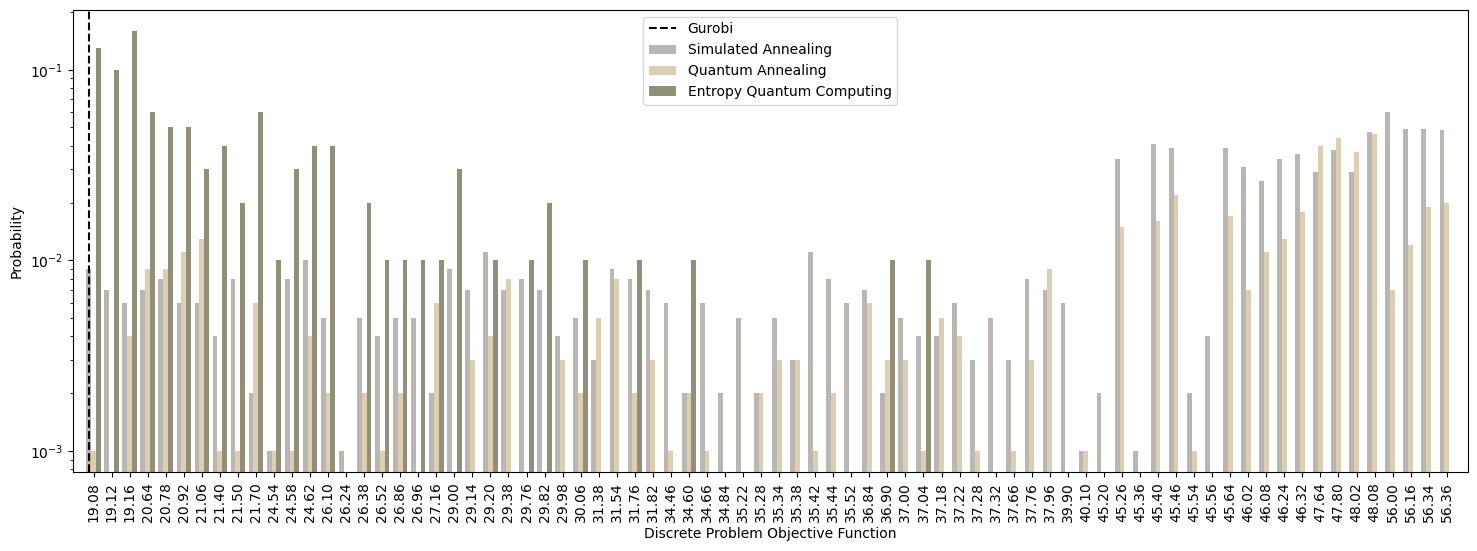

In [15]:
# ========== Plot the results of the optimization ==========
# combine the probability values that have energy values (infeasible solutions) that are > feas_ub to one value
simAnn_df_red = sum_infeas_soln(simAnn_df, feas_ub)
dwave_df_red = sum_infeas_soln(dwave_df, feas_ub)

# Add the Gurobi results to the graph 
gurobi_result = simAnn_df_red.index[0]

# Plot the results of the optimization
df_list = [simAnn_df_red, dwave_df_red, qci_result_df] 
df_names = ['Simulated Annealing', 'Quantum Annealing', 'Entropy Quantum Computing'] 
df_colors = [ '#9d9795', '#cfb991', '#646040'] 

# Plot only feasible solutions
dwave_df_feas = dwave_df[dwave_df.index < feas_ub] 
simAnn_df_feas = simAnn_df[simAnn_df.index < feas_ub]

# Plot the results of the optimization
df_list_feas = [simAnn_df_feas, dwave_df_feas, qci_result_df]  

plot_multibar_graph_discrete(df_list_feas, df_names, df_colors, feas_ub, vertical_line=gurobi_result)